In [1]:
import pathlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# ── Constants ────────────────────────────────────────────────
RANDOM_SEED  = 42
SEQUENCE_LEN = 60

DATA_DIR  = pathlib.Path("../data/hand_v2")
MODEL_DIR = pathlib.Path("../saved_models/v2")

np.random.seed(RANDOM_SEED)

# ── Success criteria ─────────────────────────────────────────
MIN_TOP1  = 0.55    # must achieve at least 55% Top-1
MIN_TOP3  = 0.75
MIN_TOP5  = 0.85
MAX_F1_ZERO_FRAC = 0.30   # at most 30% of classes can have F1 = 0
MIN_MEDIAN_F1    = 0.40

print("Evaluation gate ready.")
print(f"Success criteria: Top-1 ≥ {MIN_TOP1*100:.0f}%  |  Top-3 ≥ {MIN_TOP3*100:.0f}%  |  Top-5 ≥ {MIN_TOP5*100:.0f}%")
print(f"                  F1=0 classes < {MAX_F1_ZERO_FRAC*100:.0f}%  |  Median F1 ≥ {MIN_MEDIAN_F1:.2f}")

Evaluation gate ready.
Success criteria: Top-1 ≥ 55%  |  Top-3 ≥ 75%  |  Top-5 ≥ 85%
                  F1=0 classes < 30%  |  Median F1 ≥ 0.40


In [2]:
# Load production candidate
candidate_path = MODEL_DIR / "mudralearn_v2_candidate.keras"
model = keras.models.load_model(str(candidate_path))
print(f"Model loaded: {candidate_path}")

# Load test data
X_test = np.load(DATA_DIR / "X_test_hand.npy")
y_test = np.load(DATA_DIR / "y_test_hand.npy")

# Load label map
with open(MODEL_DIR / "label_map_v2.json") as f:
    label_map = json.load(f)     # {"0": "sign_name", ...}

class_names = [label_map[str(i)] for i in range(len(label_map))]
NUM_CLASSES = len(class_names)

print(f"X_test shape : {X_test.shape}")
print(f"y_test shape : {y_test.shape}")
print(f"Classes      : {NUM_CLASSES}")

Model loaded: ../saved_models/v2/mudralearn_v2_candidate.keras
X_test shape : (465, 60, 126)
y_test shape : (465, 204)
Classes      : 204


In [3]:
# Get predictions
y_pred_probs = model.predict(X_test, verbose=1)
y_true       = np.argmax(y_test, axis=1)
y_pred       = np.argmax(y_pred_probs, axis=1)

# Top-1
top1 = np.mean(y_true == y_pred)

# Top-K helper
def topk_acc(probs, true_labels, k):
    topk = np.argsort(probs, axis=1)[:, -k:]
    correct = sum(t in p for t, p in zip(true_labels, topk))
    return correct / len(true_labels)

top3 = topk_acc(y_pred_probs, y_true, k=3)
top5 = topk_acc(y_pred_probs, y_true, k=5)

print(f"\n{'Metric':<15} {'Value':>10} {'Min Required':>15} {'Status':>8}")
print("─" * 55)
print(f"{'Top-1':<15} {top1*100:>9.2f}% {MIN_TOP1*100:>14.0f}% {'PASS ✓' if top1 >= MIN_TOP1 else 'FAIL ✗':>8}")
print(f"{'Top-3':<15} {top3*100:>9.2f}% {MIN_TOP3*100:>14.0f}% {'PASS ✓' if top3 >= MIN_TOP3 else 'FAIL ✗':>8}")
print(f"{'Top-5':<15} {top5*100:>9.2f}% {MIN_TOP5*100:>14.0f}% {'PASS ✓' if top5 >= MIN_TOP5 else 'FAIL ✗':>8}")

 1/15 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 



Metric               Value    Min Required   Status
───────────────────────────────────────────────────────
Top-1               66.67%             55%   PASS ✓
Top-3               84.09%             75%   PASS ✓
Top-5               89.25%             85%   PASS ✓


In [4]:
# Generate classification report
report_dict = classification_report(
    y_true, y_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

# Export to CSV
df_report = pd.DataFrame(report_dict).T
csv_path = MODEL_DIR / "per_class_report_v2.csv"
df_report.to_csv(csv_path)
print(f"Per-class report saved: {csv_path}")

# Extract per-class F1 scores
f1_scores = np.array([
    report_dict[name]["f1-score"]
    for name in class_names
    if name in report_dict
])

n_zero_f1      = (f1_scores == 0).sum()
f1_zero_frac   = n_zero_f1 / NUM_CLASSES
n_above_half   = (f1_scores >= 0.5).sum()
median_f1      = np.median(f1_scores)

print(f"\nClasses with F1 = 0.0 : {n_zero_f1} ({f1_zero_frac*100:.1f}%)")
print(f"Classes with F1 ≥ 0.5 : {n_above_half} ({n_above_half/NUM_CLASSES*100:.1f}%)")
print(f"Median per-class F1   : {median_f1:.3f}")

print(f"\nF1 = 0 criterion  : {'PASS ✓' if f1_zero_frac < MAX_F1_ZERO_FRAC else 'FAIL ✗'}")
print(f"Median F1 criterion: {'PASS ✓' if median_f1 >= MIN_MEDIAN_F1 else 'FAIL ✗'}")

Per-class report saved: ../saved_models/v2/per_class_report_v2.csv

Classes with F1 = 0.0 : 102 (50.0%)
Classes with F1 ≥ 0.5 : 89 (43.6%)
Median per-class F1   : 0.143

F1 = 0 criterion  : FAIL ✗
Median F1 criterion: FAIL ✗


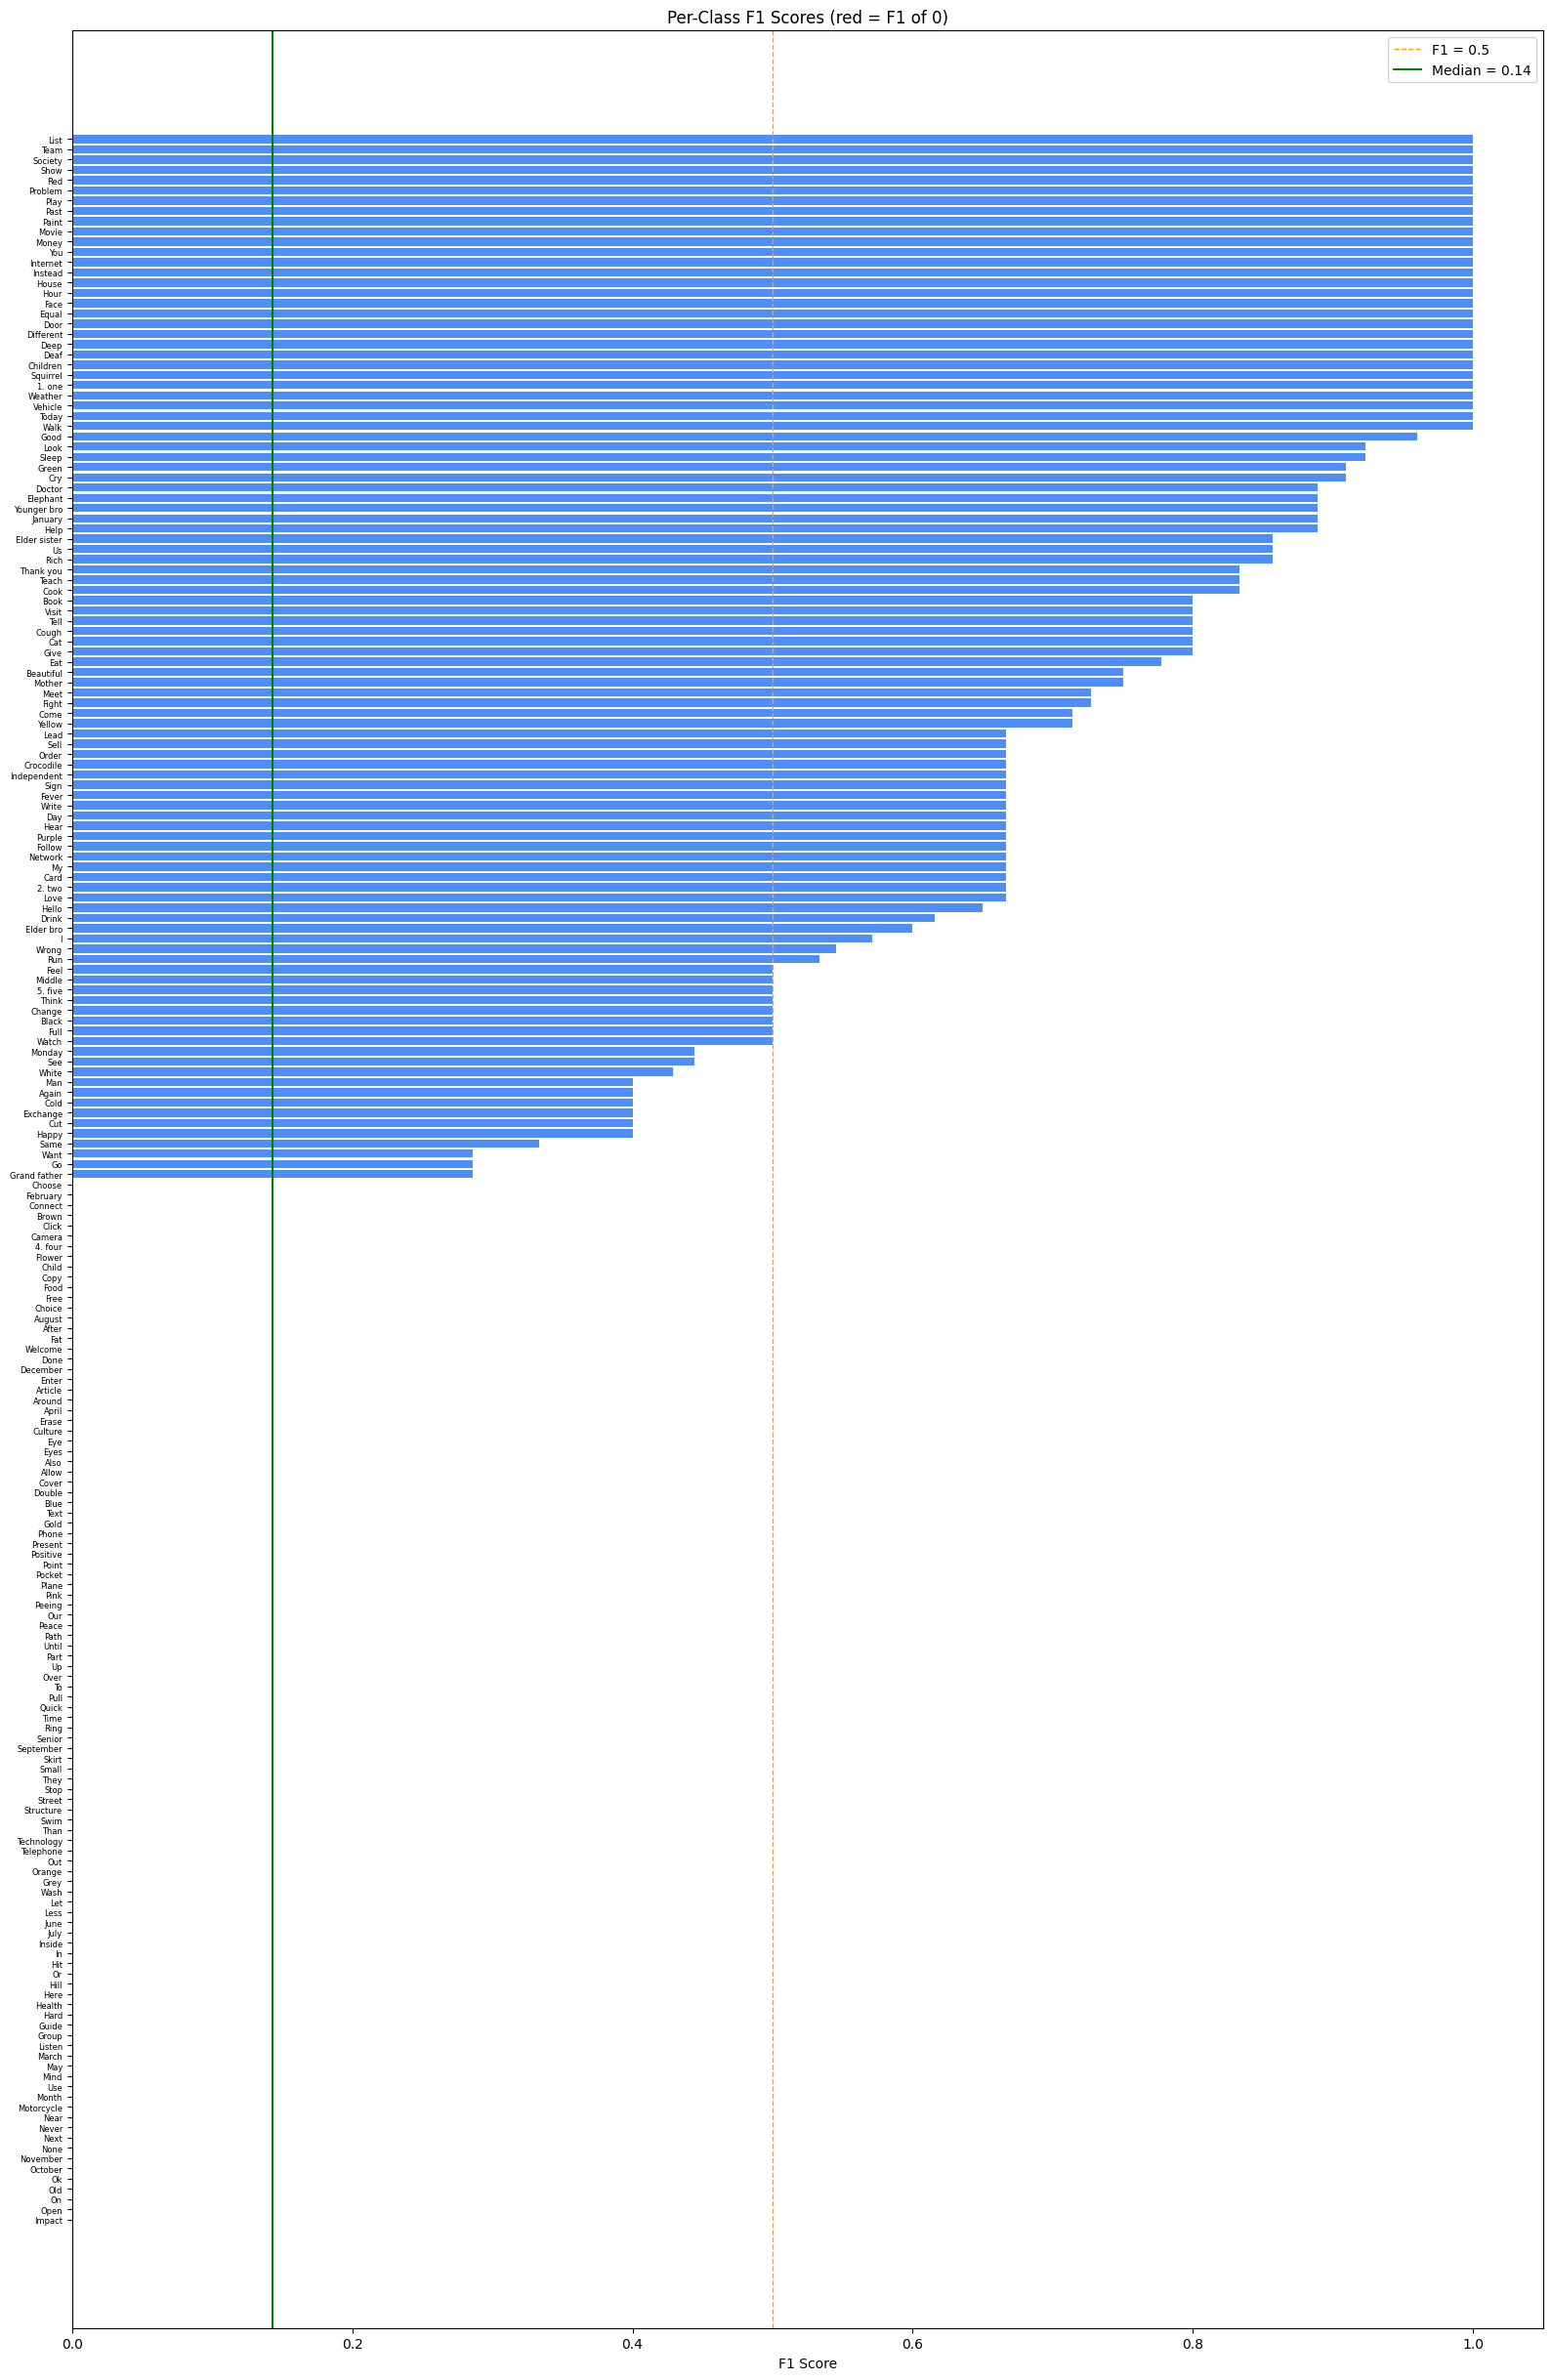

Saved: ../saved_models/v2/per_class_f1_v2.png


In [5]:
sorted_idx = np.argsort(f1_scores)
sorted_f1  = f1_scores[sorted_idx]
sorted_names = [class_names[i] for i in sorted_idx]

fig, ax = plt.subplots(figsize=(16, max(6, NUM_CLASSES * 0.12)))
colors = ["#e74c3c" if s == 0 else "#4f8ef7" for s in sorted_f1]
ax.barh(range(len(sorted_f1)), sorted_f1, color=colors)
ax.axvline(0.5, color="orange", linestyle="--", linewidth=1, label="F1 = 0.5")
ax.axvline(median_f1, color="green", linestyle="-", linewidth=1.5, label=f"Median = {median_f1:.2f}")
ax.set_yticks(range(len(sorted_names)))
ax.set_yticklabels(sorted_names, fontsize=6)
ax.set_xlabel("F1 Score")
ax.set_title("Per-Class F1 Scores (red = F1 of 0)")
ax.legend()
plt.tight_layout()
f1_plot_path = MODEL_DIR / "per_class_f1_v2.png"
plt.savefig(f1_plot_path, dpi=150)
plt.show()
print(f"Saved: {f1_plot_path}")

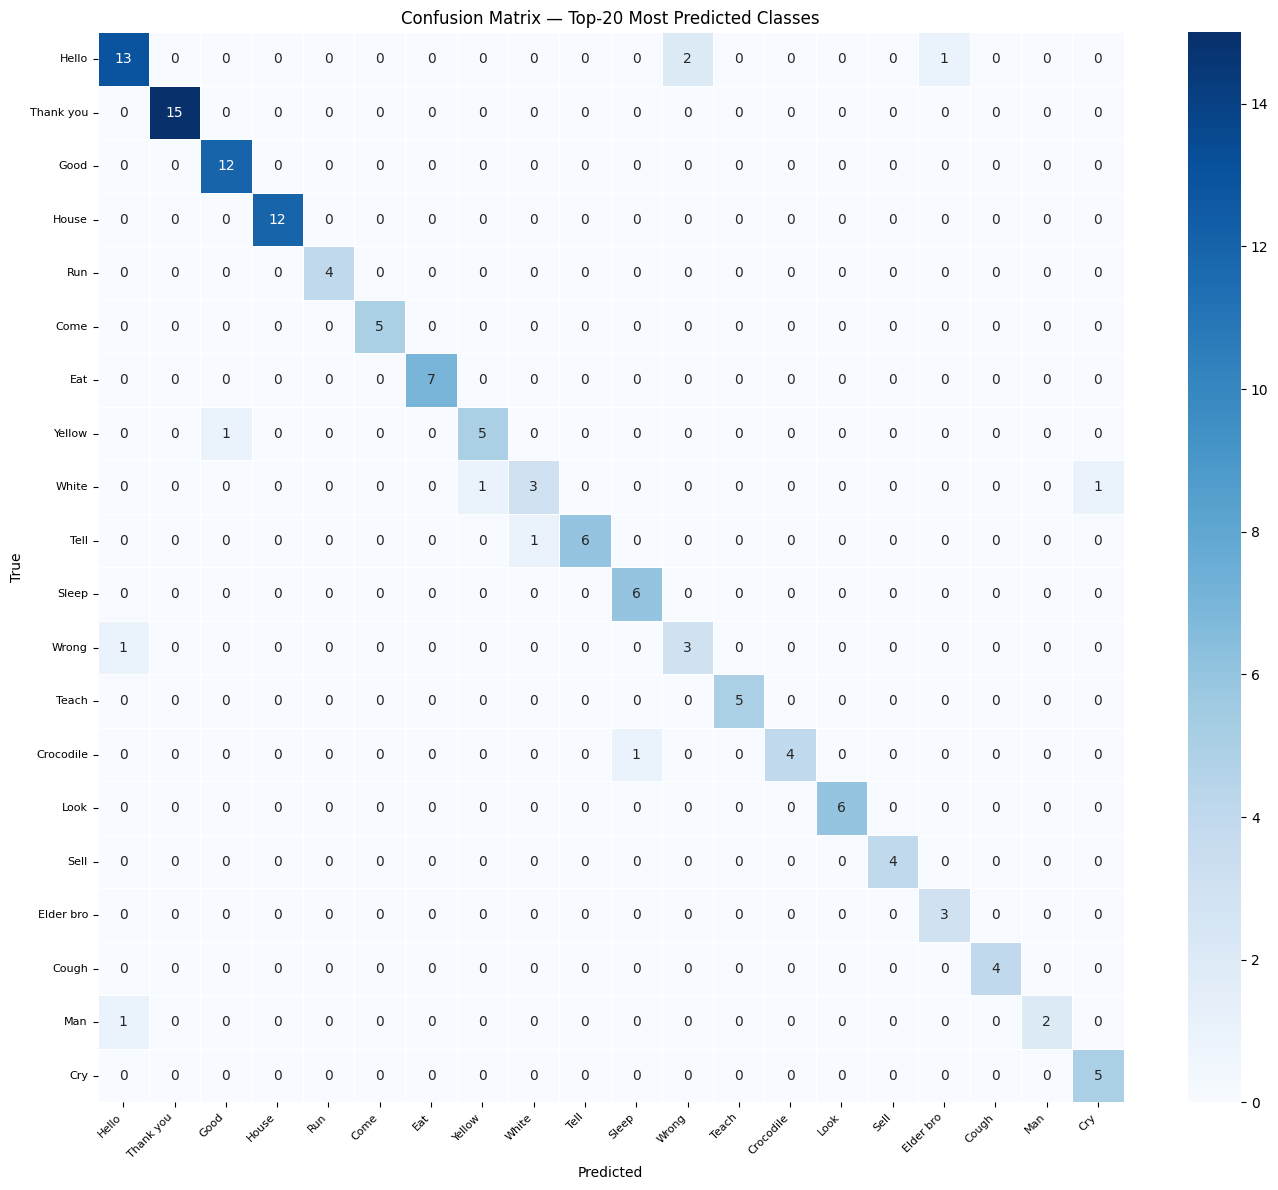

Saved: ../saved_models/v2/confusion_matrix_v2.png


In [6]:
# Find 20 most frequently predicted classes
pred_counts = pd.Series(y_pred).value_counts().head(20)
top20_idx   = pred_counts.index.tolist()
top20_names = [class_names[i] for i in top20_idx]

# Subset confusion matrix to top-20
cm_full = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
cm_sub  = cm_full[np.ix_(top20_idx, top20_idx)]

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm_sub,
    xticklabels=top20_names,
    yticklabels=top20_names,
    annot=True, fmt="d", cmap="Blues", linewidths=0.5,
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix — Top-20 Most Predicted Classes")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
cm_path = MODEL_DIR / "confusion_matrix_v2.png"
plt.savefig(cm_path, dpi=150)
plt.show()
print(f"Saved: {cm_path}")

In [7]:
# Find top-10 most confused class pairs (true ≠ predicted, sorted by frequency)
errors = [(y_true[i], y_pred[i]) for i in range(len(y_true)) if y_true[i] != y_pred[i]]

from collections import Counter
error_counts = Counter(errors)
top10_errors = error_counts.most_common(10)

print("Top-10 Most Confused Pairs:")
print(f"  {'True Sign':<30} {'Predicted Sign':<30} {'Count':>6}")
print("─" * 70)
for (true_idx, pred_idx), count in top10_errors:
    true_name = class_names[true_idx]
    pred_name = class_names[pred_idx]
    print(f"  {true_name:<30} {pred_name:<30} {count:>6}")

Top-10 Most Confused Pairs:
  True Sign                      Predicted Sign                  Count
──────────────────────────────────────────────────────────────────────
  Want                           Hello                               4
  Grand father                   Man                                 3
  Hello                          Wrong                               2
  Cold                           Run                                 2
  Change                         Run                                 2
  Go                             Book                                2
  See                            Monday                              2
  Purple                         White                               2
  Thank you                      See                                 2
  Point                          To                                  1


Per-Category Accuracy:
  Category              Correct    Total   Accuracy
────────────────────────────────────────────────────
  Places                     12       12     100.0%
  Greetings                  28       34      82.4%
  Months                      4        5      80.0%
  Numbers                     4        5      80.0%
  Colors                     23       32      71.9%
  Days                       12       17      70.6%
  Nouns                      57       83      68.7%
  People                     23       34      67.6%
  Verbs                     109      164      66.5%
  Adjectives                 34       55      61.8%
  Vehicles                    1        3      33.3%
  Adverb                      3       10      30.0%
  Preposition                 0       11       0.0%


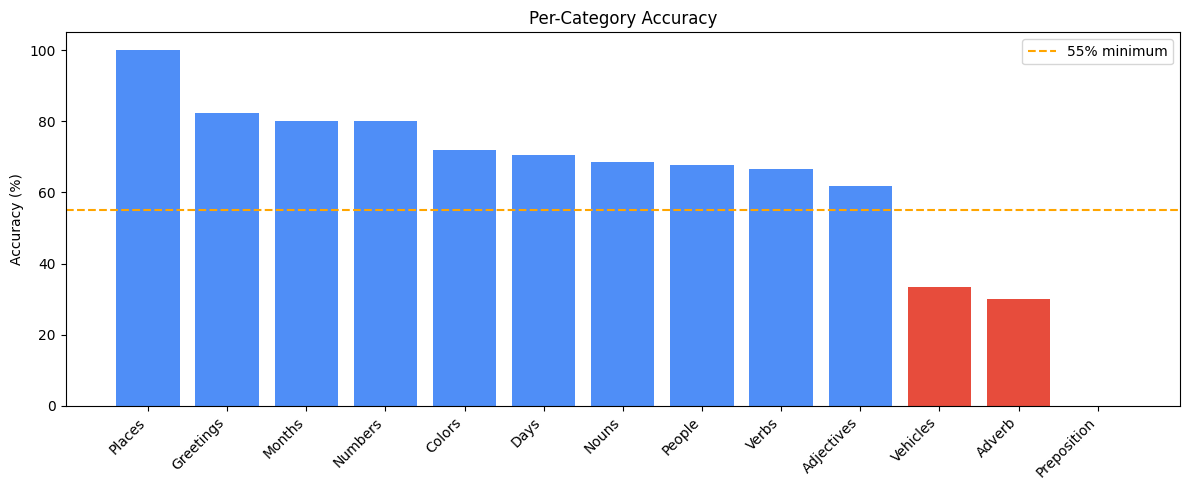

In [8]:
# Load the label encoder to get sign → category mapping
# Category = parent directory name from Dataset - Original
with open(MODEL_DIR / "label_map_v2.json") as f:
    label_map_v2 = json.load(f)

# Build sign → category lookup from the original folder structure
import pathlib
ORIG_ROOT = pathlib.Path("../data/archive/Dataset - Original")
sign_to_cat = {}
for cat_dir in ORIG_ROOT.iterdir():
    if not cat_dir.is_dir():
        continue
    for sign_dir in cat_dir.iterdir():
        if sign_dir.is_dir():
            sign_to_cat[sign_dir.name] = cat_dir.name

# Map class index → category
idx_to_cat = {i: sign_to_cat.get(name, "Unknown") for i, name in enumerate(class_names)}

# Per-category accuracy
cat_correct = {}
cat_total   = {}
for true_i, pred_i in zip(y_true, y_pred):
    cat = idx_to_cat[true_i]
    cat_total[cat]   = cat_total.get(cat, 0) + 1
    cat_correct[cat] = cat_correct.get(cat, 0) + (1 if true_i == pred_i else 0)

cat_acc = {cat: cat_correct[cat] / cat_total[cat] for cat in cat_total}
sorted_cats = sorted(cat_acc.items(), key=lambda x: x[1], reverse=True)

print("Per-Category Accuracy:")
print(f"  {'Category':<20} {'Correct':>8} {'Total':>8} {'Accuracy':>10}")
print("─" * 52)
for cat, acc in sorted_cats:
    print(f"  {cat:<20} {cat_correct[cat]:>8} {cat_total[cat]:>8} {acc*100:>9.1f}%")

# Bar chart
fig, ax = plt.subplots(figsize=(12, 5))
cats   = [c for c, _ in sorted_cats]
accs   = [a for _, a in sorted_cats]
colors = ["#4f8ef7" if a >= 0.55 else "#e74c3c" for a in accs]
ax.bar(cats, [a * 100 for a in accs], color=colors)
ax.axhline(55, color="orange", linestyle="--", label="55% minimum")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Per-Category Accuracy")
plt.xticks(rotation=45, ha="right")
ax.legend()
plt.tight_layout()
cat_plot_path = MODEL_DIR / "category_accuracy_v2.png"
plt.savefig(cat_plot_path, dpi=150)
plt.show()

In [9]:
# Evaluate all success criteria
criteria = {
    "Top-1 ≥ 55%"              : top1 >= MIN_TOP1,
    "Top-3 ≥ 75%"              : top3 >= MIN_TOP3,
    "Top-5 ≥ 85%"              : top5 >= MIN_TOP5,
    "F1=0 classes < 30%"       : f1_zero_frac < MAX_F1_ZERO_FRAC,
    f"Median F1 ≥ {MIN_MEDIAN_F1}": median_f1 >= MIN_MEDIAN_F1,
}

gate_pass = all(criteria.values())

print("=" * 55)
print("GATE CHECK — ALL CRITERIA MUST PASS FOR STEP 7")
print("=" * 55)
for criterion, passed in criteria.items():
    print(f"  {'PASS ✓' if passed else 'FAIL ✗'}  {criterion}")
print("─" * 55)
print(f"\n  GATE STATUS: {'✅ PASS — Proceed to Step 7' if gate_pass else '❌ FAIL — Fix model before Step 7'}")
print()

if not gate_pass:
    print("Diagnosis guide:")
    if top1 < MIN_TOP1 and top3 >= MIN_TOP3:
        print("  • Top-1 low, Top-3 high → model partially right, not confident")
        print("    Fix: add label_smoothing=0.1 to loss and retrain")
    if f1_zero_frac >= MAX_F1_ZERO_FRAC:
        print("  • Many classes F1=0 → class imbalance too severe")
        print("    Fix: increase AUG_FACTOR to 10 for classes with < 5 samples")
    if top1 < 0.40 and top3 < 0.60:
        print("  • Both low → possible underfitting")
        print("    Fix: increase GRU units to 256, raise EarlyStopping patience to 30")

GATE CHECK — ALL CRITERIA MUST PASS FOR STEP 7
  PASS ✓  Top-1 ≥ 55%
  PASS ✓  Top-3 ≥ 75%
  PASS ✓  Top-5 ≥ 85%
  FAIL ✗  F1=0 classes < 30%
  FAIL ✗  Median F1 ≥ 0.4
───────────────────────────────────────────────────────

  GATE STATUS: ❌ FAIL — Fix model before Step 7

Diagnosis guide:
  • Many classes F1=0 → class imbalance too severe
    Fix: increase AUG_FACTOR to 10 for classes with < 5 samples


In [10]:
print("=" * 50)
print("FINDINGS SUMMARY")
print("=" * 50)
print(f"Top-1           : {top1*100:.2f}%")
print(f"Top-3           : {top3*100:.2f}%")
print(f"Top-5           : {top5*100:.2f}%")
print(f"Classes F1 = 0  : {n_zero_f1} ({f1_zero_frac*100:.1f}%)")
print(f"Median F1       : {median_f1:.3f}")
if top10_errors:
    t, p = top10_errors[0][0]
    print(f"Most confused   : {class_names[t]} → {class_names[p]}")
print(f"GATE STATUS     : {'PASS' if gate_pass else 'FAIL'}")
print("=" * 50)

FINDINGS SUMMARY
Top-1           : 66.67%
Top-3           : 84.09%
Top-5           : 89.25%
Classes F1 = 0  : 102 (50.0%)
Median F1       : 0.143
Most confused   : Want → Hello
GATE STATUS     : FAIL
